Initializing BO with 41 experiments...

TRAINING ALL MODELS (Regression & Classification)
Size         | Q²: 0.352 | MAE: ±4.847
GSD          | Q²: -0.147 | MAE: ±0.166
Squareness   | Q²: -0.293 | MAE: ±0.051

MODEL SUMMARY
Size        : Uncertainty ±4.847 (MAE)
GSD         : Uncertainty ±0.166 (MAE)
Squareness  : Uncertainty ±0.051 (MAE)

GENERATING FIGURES


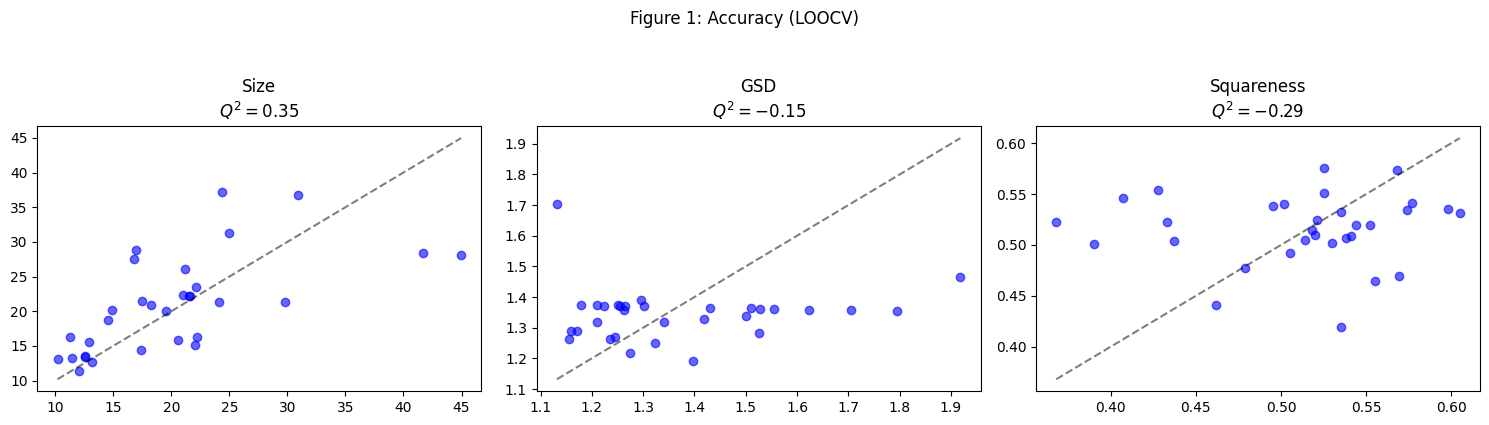

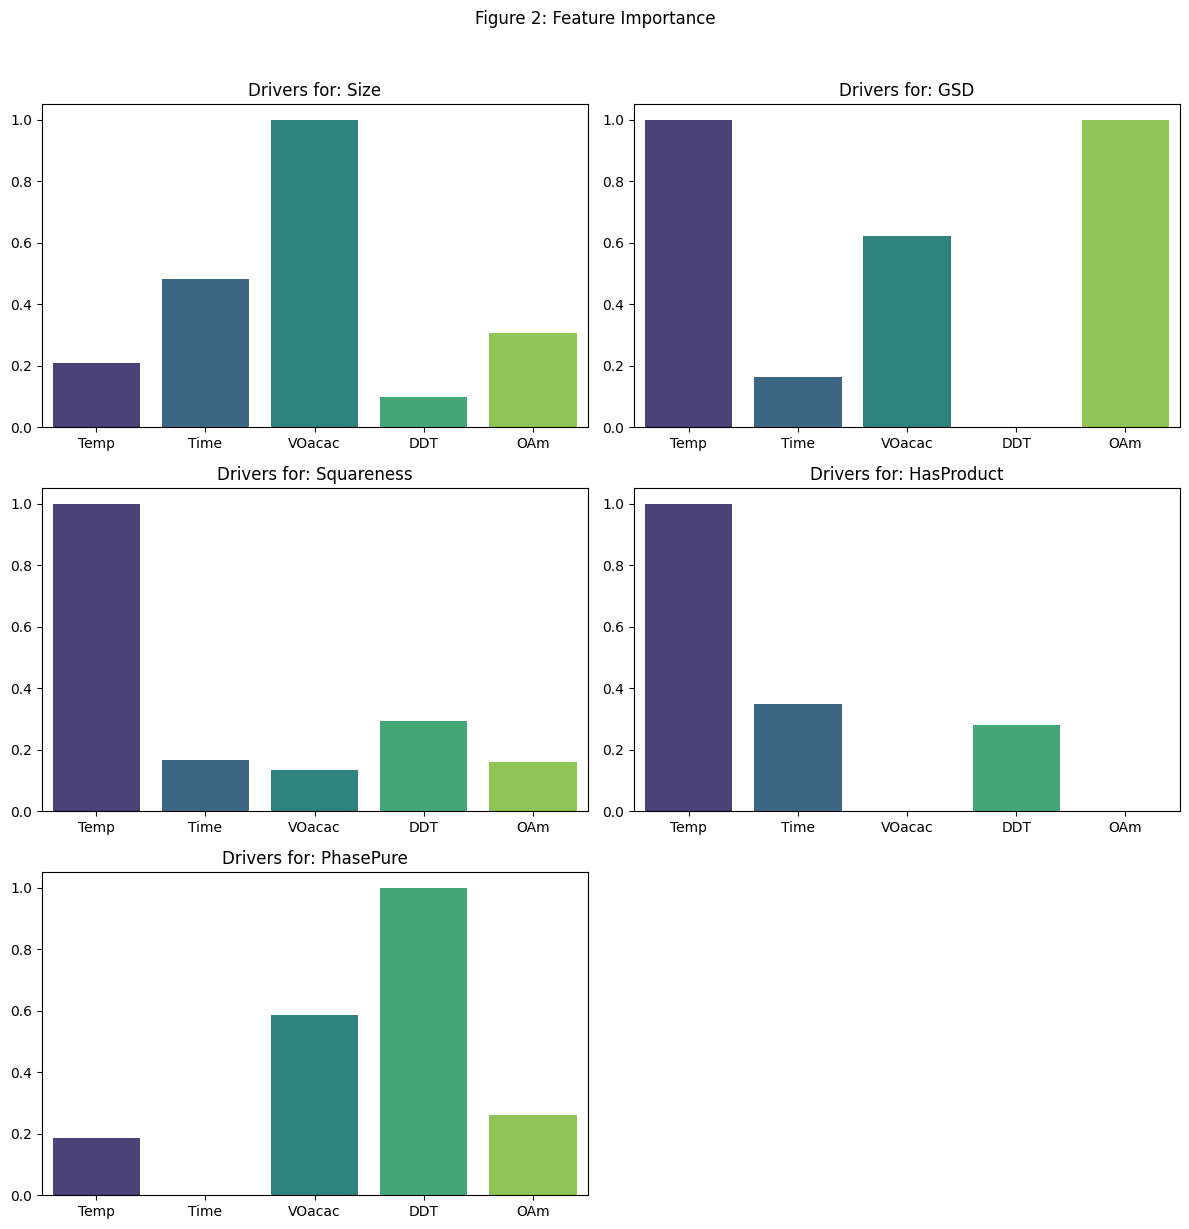

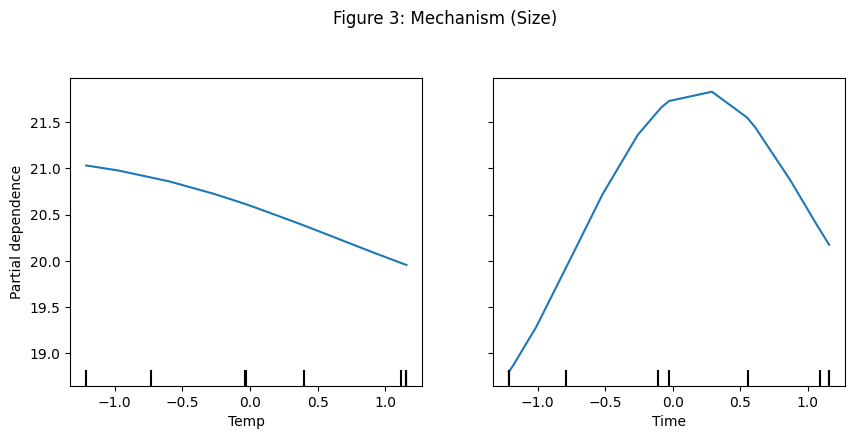

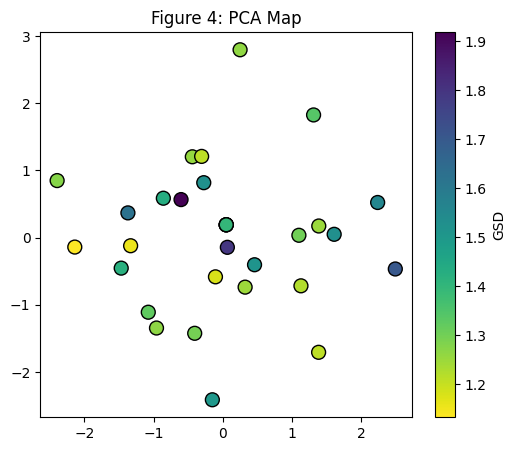

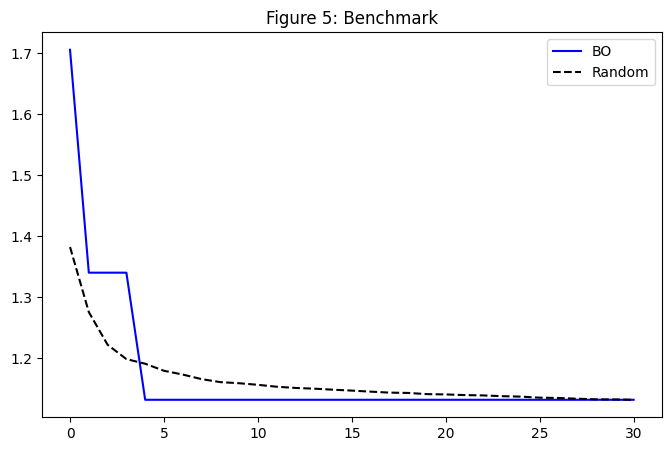


CALCULATING NEXT EXPERIMENT (Target: 25.0 nm)
  Configuration -> Size Penalty: 2.0, GSD Importance: 1.0

RECOMMENDED CONDITIONS:
  Temp      : 308.63
  Time      : 52.78
  VOacac    : 0.52
  DDT       : 1.41
  OAm       : 3.37

EXPECTED RESULT:
  Size:       25.00 ± 4.51 nm
  GSD:        1.368 ± 0.201
  Squareness: 0.569 ± 0.045


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import differential_evolution
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessRegressor, GaussianProcessClassifier
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C, RBF
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score
from sklearn.inspection import PartialDependenceDisplay
from pathlib import Path
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. CONFIGURATION
# ==========================================
FACTOR_ORDER = ["Temp", "Time", "VOacac", "DDT", "OAm"]
BOUNDS = {
    "Temp":   (260, 310),    # °C
    "Time":   (8, 90),       # minutes
    "VOacac": (0.08, 0.66),  # M
    "DDT":    (0.5, 6.0),    # mL
    "OAm":    (3.0, 15.0)    # mL
}

# ==========================================
# 2. MAIN BO SYSTEM
# ==========================================
class PublicationBO:
    def __init__(self, df, target_size=16):
        self.df = df
        self.target_size = target_size
        self.factors = FACTOR_ORDER

        print(f"Initializing BO with {len(df)} experiments...")
        self._prepare_data()
        self._train_models_loocv()
        self._simulate_random_baseline()
        self.print_summary()

    def _prepare_data(self):
        # 1. Regression Data (Only valid product)
        valid_mask = (self.df['HasProduct'] == 1) & \
                     self.df[['Size', 'GSD', 'Squareness']].notna().all(axis=1)
        self.reg_data = self.df[valid_mask].copy()

        # 2. Classification Data (All experiments)
        self.cls_data = self.df.copy()

        # 3. Scalers
        self.X_scaler = StandardScaler().fit(self.cls_data[self.factors])

    def _train_models_loocv(self):
        print("\n" + "="*60)
        print("TRAINING ALL MODELS (Regression & Classification)")
        print("="*60)

        self.models = {}
        self.model_stats = {}

        # --- A. REGRESSION MODELS ---
        kernel_reg = C(1.0) * Matern(length_scale=[1.0]*5, nu=2.5) + WhiteKernel(0.1)
        X_reg = self.X_scaler.transform(self.reg_data[self.factors])

        for response in ['Size', 'GSD', 'Squareness']:
            y = self.reg_data[response].values

            # LOOCV
            loo = LeaveOneOut()
            y_true, y_pred = [], []
            for train_idx, test_idx in loo.split(X_reg):
                try:
                    gp = GaussianProcessRegressor(kernel=kernel_reg, normalize_y=True, n_restarts_optimizer=0)
                    gp.fit(X_reg[train_idx], y[train_idx])
                    y_pred.append(gp.predict(X_reg[test_idx])[0])
                    y_true.append(y[test_idx][0])
                except: continue

            # Final Fit
            final_gp = GaussianProcessRegressor(kernel=kernel_reg, n_restarts_optimizer=5, normalize_y=True, random_state=42)
            final_gp.fit(X_reg, y)
            self.models[response] = final_gp

            q2 = r2_score(y_true, y_pred)
            mae = mean_absolute_error(y_true, y_pred)
            self.model_stats[response] = {'q2': q2, 'mae': mae, 'y_true': np.array(y_true), 'y_pred': np.array(y_pred)}
            print(f"{response:12s} | Q²: {q2:.3f} | MAE: ±{mae:.3f}")

        # --- B. CLASSIFICATION MODELS ---
        kernel_cls = C(1.0) * RBF(length_scale=[1.0]*5)
        X_all = self.X_scaler.transform(self.cls_data[self.factors])

        # Has Product
        self.models['HasProduct'] = GaussianProcessClassifier(kernel=kernel_cls, n_restarts_optimizer=3)
        self.models['HasProduct'].fit(X_all, self.cls_data['HasProduct'])

        # Phase Pure
        if 'PhasePure' in self.df.columns:
            mask = self.cls_data['HasProduct'] == 1
            if mask.sum() > 5:
                self.models['PhasePure'] = GaussianProcessClassifier(kernel=kernel_cls, n_restarts_optimizer=3)
                self.models['PhasePure'].fit(X_all[mask], self.cls_data.loc[mask, 'PhasePure'])

    def _simulate_random_baseline(self):
        n_sims = 100
        n_steps = len(self.reg_data)
        self.random_curve = np.zeros(n_steps)
        vals = self.reg_data['GSD'].values
        for i in range(n_sims):
            self.random_curve += np.minimum.accumulate(np.random.permutation(vals))
        self.random_curve /= n_sims

    def print_summary(self):
        print("\n" + "="*60)
        print("MODEL SUMMARY")
        print("="*60)
        for resp in ['Size', 'GSD', 'Squareness']:
            mae = self.model_stats[resp]['mae']
            print(f"{resp:12s}: Uncertainty ±{mae:.3f} (MAE)")

    def predict(self, X):
        X_scaled = self.X_scaler.transform(X)
        preds = {}

        for r in ['Size', 'GSD', 'Squareness']:
            mu, std = self.models[r].predict(X_scaled, return_std=True)
            preds[r] = {'mean': mu, 'std': std}

        preds['P_product'] = self.models['HasProduct'].predict_proba(X_scaled)[:, 1]
        if 'PhasePure' in self.models:
            preds['P_pure'] = self.models['PhasePure'].predict_proba(X_scaled)[:, 1]

        return preds

# ==========================================
# 3. VISUALIZATION
# ==========================================
class BOVisualizer:
    def __init__(self, bo_system):
        self.bo = bo_system

    def create_publication_report(self):
        print("\n" + "="*60)
        print("GENERATING FIGURES")
        print("="*60)
        self.plot_prediction_accuracy()
        self.plot_all_feature_importance()
        self.plot_partial_dependence()
        self.plot_search_space()
        self.plot_benchmark()

    def plot_prediction_accuracy(self):
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        for i, resp in enumerate(['Size', 'GSD', 'Squareness']):
            stats = self.bo.model_stats[resp]
            ax = axes[i]
            ax.scatter(stats['y_true'], stats['y_pred'], alpha=0.6, c='blue')
            lo, hi = min(stats['y_true'].min(), stats['y_pred'].min()), max(stats['y_true'].max(), stats['y_pred'].max())
            ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5)
            ax.set_title(f"{resp}\n$Q^2={stats['q2']:.2f}$")
        plt.suptitle("Figure 1: Accuracy (LOOCV)", y=1.05)
        plt.tight_layout()
        plt.show()

    def plot_all_feature_importance(self):
        targets = [k for k in self.bo.models.keys() if k in ['Size', 'GSD', 'Squareness', 'HasProduct', 'PhasePure']]
        n_plots = len(targets)
        rows = (n_plots + 1) // 2
        fig, axes = plt.subplots(rows, 2, figsize=(12, 4 * rows))
        axes = axes.flatten()

        for i, target in enumerate(targets):
            ax = axes[i]
            model = self.bo.models[target]

            def find_length_scales(kernel):
                stack = [kernel]
                while stack:
                    k = stack.pop()
                    if hasattr(k, 'length_scale'):
                        ls = np.atleast_1d(k.length_scale)
                        if len(ls) == len(self.bo.factors): return ls
                    if hasattr(k, 'k1'): stack.append(k.k1)
                    if hasattr(k, 'k2'): stack.append(k.k2)
                return None

            ls = find_length_scales(model.kernel_)
            if ls is not None:
                importance = 1.0 / ls
                importance = importance / importance.max()
                sns.barplot(x=self.bo.factors, y=importance, ax=ax, palette='viridis')
                ax.set_title(f"Drivers for: {target}")
            else:
                ax.text(0.5, 0.5, "Isotropic Kernel", ha='center')

        for j in range(i+1, len(axes)): axes[j].axis('off')
        plt.suptitle("Figure 2: Feature Importance", y=1.02)
        plt.tight_layout()
        plt.show()

    def plot_partial_dependence(self):
        fig, ax = plt.subplots(figsize=(10, 4))
        PartialDependenceDisplay.from_estimator(
            self.bo.models['Size'], self.bo.X_scaler.transform(self.bo.reg_data[self.bo.factors]),
            features=[0, 1], feature_names=self.bo.factors, kind='average', ax=ax
        )
        plt.suptitle("Figure 3: Mechanism (Size)", y=1.05)
        plt.show()

    def plot_search_space(self):
        X = self.bo.X_scaler.transform(self.bo.reg_data[self.bo.factors])
        pca = PCA(n_components=2).fit_transform(X)
        plt.figure(figsize=(6, 5))
        plt.scatter(pca[:, 0], pca[:, 1], c=self.bo.reg_data['GSD'], cmap='viridis_r', s=100, edgecolors='k')
        plt.colorbar(label='GSD')
        plt.title("Figure 4: PCA Map")
        plt.show()

    def plot_benchmark(self):
        plt.figure(figsize=(8, 5))
        bo = np.minimum.accumulate(self.bo.reg_data['GSD'].values)
        rand = self.bo.random_curve[:len(bo)]
        plt.plot(bo, 'b-', label='BO')
        plt.plot(rand, 'k--', label='Random')
        plt.legend(); plt.title("Figure 5: Benchmark")
        plt.show()

# ==========================================
def run_pipeline(df, target_size=20.0, size_priority='high'):
    bo = PublicationBO(df, target_size=target_size)
    BOVisualizer(bo).create_publication_report()

    print("\n" + "="*60)
    print(f"CALCULATING NEXT EXPERIMENT (Target: {target_size} nm)")
    print("="*60)

    # Define Weights based on priority
    if size_priority == 'high':
        w_size = 2.0  # Heavy penalty: Forces the model to hit size
        w_gsd = 1.0
    else:
        w_size = 0.1  # Light penalty: Prefers quality (GSD) over size
        w_gsd = 2.0

    print(f"  Configuration -> Size Penalty: {w_size}, GSD Importance: {w_gsd}")

    def acquisition(x):
        preds = bo.predict(pd.DataFrame([x], columns=FACTOR_ORDER))

        # 1. Size Penalty (The main driver now)
        size_diff = abs(preds['Size']['mean'][0] - target_size)
        penalty_size = size_diff * w_size

        # 2. Quality Objectives
        score_gsd = preds['GSD']['mean'][0] * w_gsd
        score_sq = preds['Squareness']['mean'][0] * 1.0

        # 3. Feasibility Penalties (Constraints)
        penalty_product = 100.0 if preds['P_product'][0] < 0.5 else 0.0

        # Total Loss (Minimize this)
        loss = score_gsd - score_sq + penalty_size + penalty_product
        return loss

    # Run Optimizer
    res = differential_evolution(acquisition, [BOUNDS[f] for f in FACTOR_ORDER], seed=42)
    best = dict(zip(FACTOR_ORDER, res.x))

    print("\nRECOMMENDED CONDITIONS:")
    for k, v in best.items(): print(f"  {k:10s}: {v:.2f}")

    # PREDICTION
    pred = bo.predict(pd.DataFrame([best]))
    predicted_size = pred['Size']['mean'][0]

    print("\nEXPECTED RESULT:")
    print(f"  Size:       {predicted_size:.2f} ± {pred['Size']['std'][0]:.2f} nm")
    print(f"  GSD:        {pred['GSD']['mean'][0]:.3f} ± {pred['GSD']['std'][0]:.3f}")
    print(f"  Squareness: {pred['Squareness']['mean'][0]:.3f} ± {pred['Squareness']['std'][0]:.3f}")

    # SANITY CHECK
    if abs(predicted_size - target_size) > 3.0:
        print("\n⚠️ WARNING: The model could not reach your target size!")
        print("  It's possible 25nm is outside the accessible range of your current chemistry/data.")
        print("  Try checking the 'Feature Importance' graph to see what drives size (usually Temp).")

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    if 'df' in locals():
        # Try running with high priority on size
        run_pipeline(df, target_size=25.0, size_priority='high')
    else:
        print("Load 'df' first!")